# Lab 6
**Masking Techniques: Median and Laplacian Filters**

**Note:** It is a good practice to use input image having salt and pepper noise.

## Objective:

1. Design a program to read an image (.jpg) and apply median filter with mask dimensionality of 3x3 on each plane (total 3 planes). Display the input image and processed (output) image.2. Formulate a program to read an image (.jpg) and apply Laplacian filter with mask dimensionality of 3x3 on each plane (total 3 planes). Also, employ sharpening (bringing out of range pixel values within range). Display the input image and processed (output) image.

In [17]:
import numpy as np 
import cv2 
import matplotlib.pyplot as plt 

In [18]:
def print_img(img, note=""):
    plt.imshow(img)
    plt.axis("off") 
    plt.title(f"{note}, {img.shape[1]}x{img.shape[0]}")

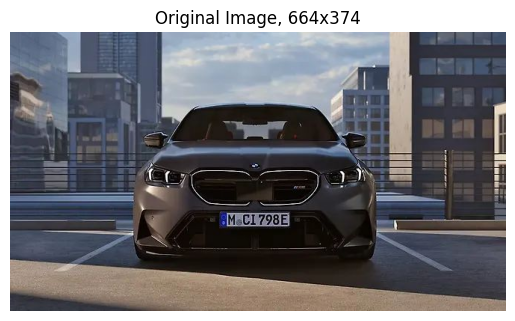

In [19]:
img  = cv2.cvtColor(cv2.imread("Images/m5.jpg"), cv2.COLOR_BGR2RGB)
print_img(img, "Original Image")

In [20]:
def add_salt_and_pepper_noise(image, amount=0.02):
    """
    amount: Probability of noise (0.02 means 2% of pixels will be noisy)
    """
    output = np.copy(image)
    
    probs = np.random.random(output.shape[:2])

    output[probs < (amount / 2)] = 0

    output[(probs >= (amount / 2)) & (probs < amount)] = 255
    
    return output

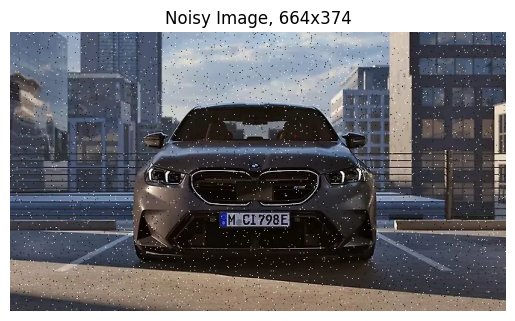

In [21]:
img_noisy = add_salt_and_pepper_noise(img, amount=0.02)
print_img(img_noisy, "Noisy Image")

In [22]:
import random

def quickselect(arr, k):
    """
    Finds the k-th smallest element in a list (0-indexed).
    For the median, k should be len(arr) // 2.
    """
    if len(arr) == 1: return arr[0]

    pivot = random.choice(arr)

    lows = [el for el in arr if el < pivot]
    highs = [el for el in arr if el > pivot]
    pivots = [el for el in arr if el == pivot]

    if k < len(lows): return quickselect(lows, k)
    
    elif k < len(lows) + len(pivots): return pivots[0]
    
    else: return quickselect(highs, k - len(lows) - len(pivots))

def find_median(arr):
    if len(arr) == 0:
        return None
    
    n = len(arr)
    if n % 2 == 1: return quickselect(arr, n // 2)
    else:
        left_mid = quickselect(arr, n // 2 - 1)
        right_mid = quickselect(arr, n // 2)
        return (left_mid + right_mid) / 2

In [23]:
med_img = np.copy(img_noisy) 
for i in range(1, img.shape[0] - 1):
    for j in range(1, img.shape[1] - 1):
        for c in range(3):
            neighborhood = img_noisy[i-1:i+2, j-1:j+2, c].flatten()
            med_img[i, j, c] = find_median(neighborhood) 

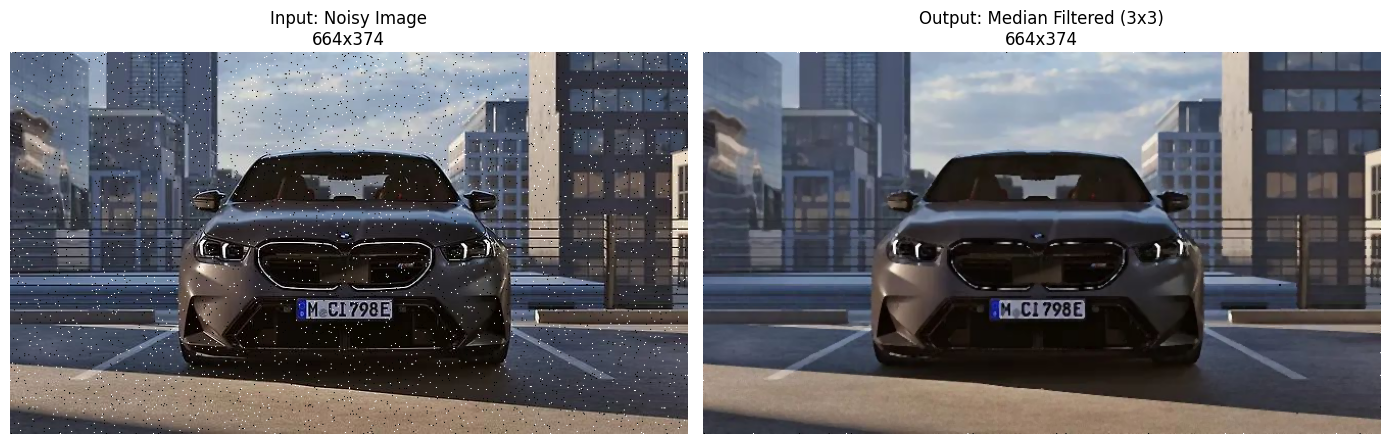

In [24]:
# Display input and output for Part 1
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].imshow(img_noisy)
axs[0].axis("off")
axs[0].set_title(f"Input: Noisy Image\n{img_noisy.shape[1]}x{img_noisy.shape[0]}")

axs[1].imshow(med_img)
axs[1].axis("off")
axs[1].set_title(f"Output: Median Filtered (3x3)\n{med_img.shape[1]}x{med_img.shape[0]}")
plt.tight_layout()
plt.show()

In [25]:
# Define Laplacian masks
laplacian_mask_4d = np.array([[0, 1, 0],
                              [1, -4, 1],
                              [0, 1, 0]])

laplacian_mask_8d = np.array([[1, 1, 1],
                              [1, -8, 1],
                              [1, 1, 1]])

In [26]:
# Apply Laplacian filter on median filtered image
med_img_float = med_img.astype(np.float32)
lap_4d_img = np.zeros_like(med_img_float)
lap_8d_img = np.zeros_like(med_img_float)

# Apply Laplacian masks on each color plane
for i in range(1, img.shape[0] - 1):
    for j in range(1, img.shape[1] - 1):
        for c in range(3):
            neighborhood = med_img_float[i-1:i+2, j-1:j+2, c]
            lap_4d_img[i, j, c] = np.sum(neighborhood * laplacian_mask_4d)
            lap_8d_img[i, j, c] = np.sum(neighborhood * laplacian_mask_8d)

In [27]:
# Scale Laplacian outputs for edge visualization (white edges on black background)
def scale_for_display(img):
    # Take absolute value to get edge strength
    img_abs = np.abs(img)
    # Initialize output
    result = np.zeros_like(img_abs, dtype=np.uint8)
    
    # Process each color plane (R, G, B) separately
    for c in range(3):
        plane = img_abs[:, :, c]
        plane_max = np.max(plane)
        if plane_max > 0:
            # Scale each plane to [0, 255] range independently
            result[:, :, c] = (plane / plane_max * 255).astype(np.uint8)
        else:
            result[:, :, c] = plane.astype(np.uint8)
    
    return result

lap_4d_edges = scale_for_display(lap_4d_img)
lap_8d_edges = scale_for_display(lap_8d_img)

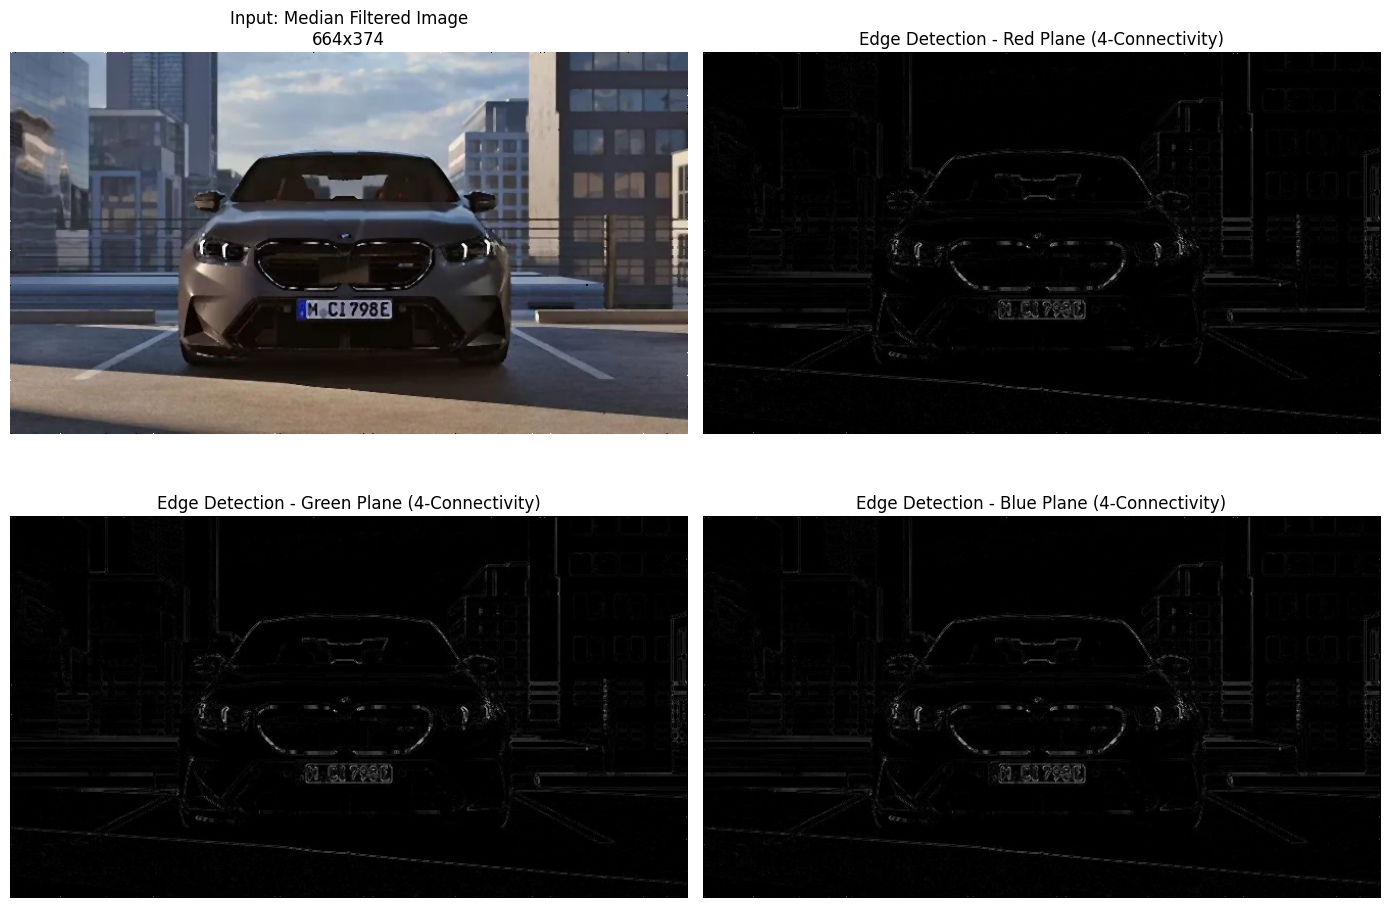

In [28]:
# Display edge detection results (4-connectivity) - each RGB plane separately
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Original image
axs[0, 0].imshow(med_img)
axs[0, 0].axis("off")
axs[0, 0].set_title(f"Input: Median Filtered Image\n{med_img.shape[1]}x{med_img.shape[0]}")

# Red plane
axs[0, 1].imshow(lap_4d_edges[:, :, 0], cmap='gray')
axs[0, 1].axis("off")
axs[0, 1].set_title("Edge Detection - Red Plane (4-Connectivity)")

# Green plane
axs[1, 0].imshow(lap_4d_edges[:, :, 1], cmap='gray')
axs[1, 0].axis("off")
axs[1, 0].set_title("Edge Detection - Green Plane (4-Connectivity)")

# Blue plane
axs[1, 1].imshow(lap_4d_edges[:, :, 2], cmap='gray')
axs[1, 1].axis("off")
axs[1, 1].set_title("Edge Detection - Blue Plane (4-Connectivity)")

plt.tight_layout()
plt.show()

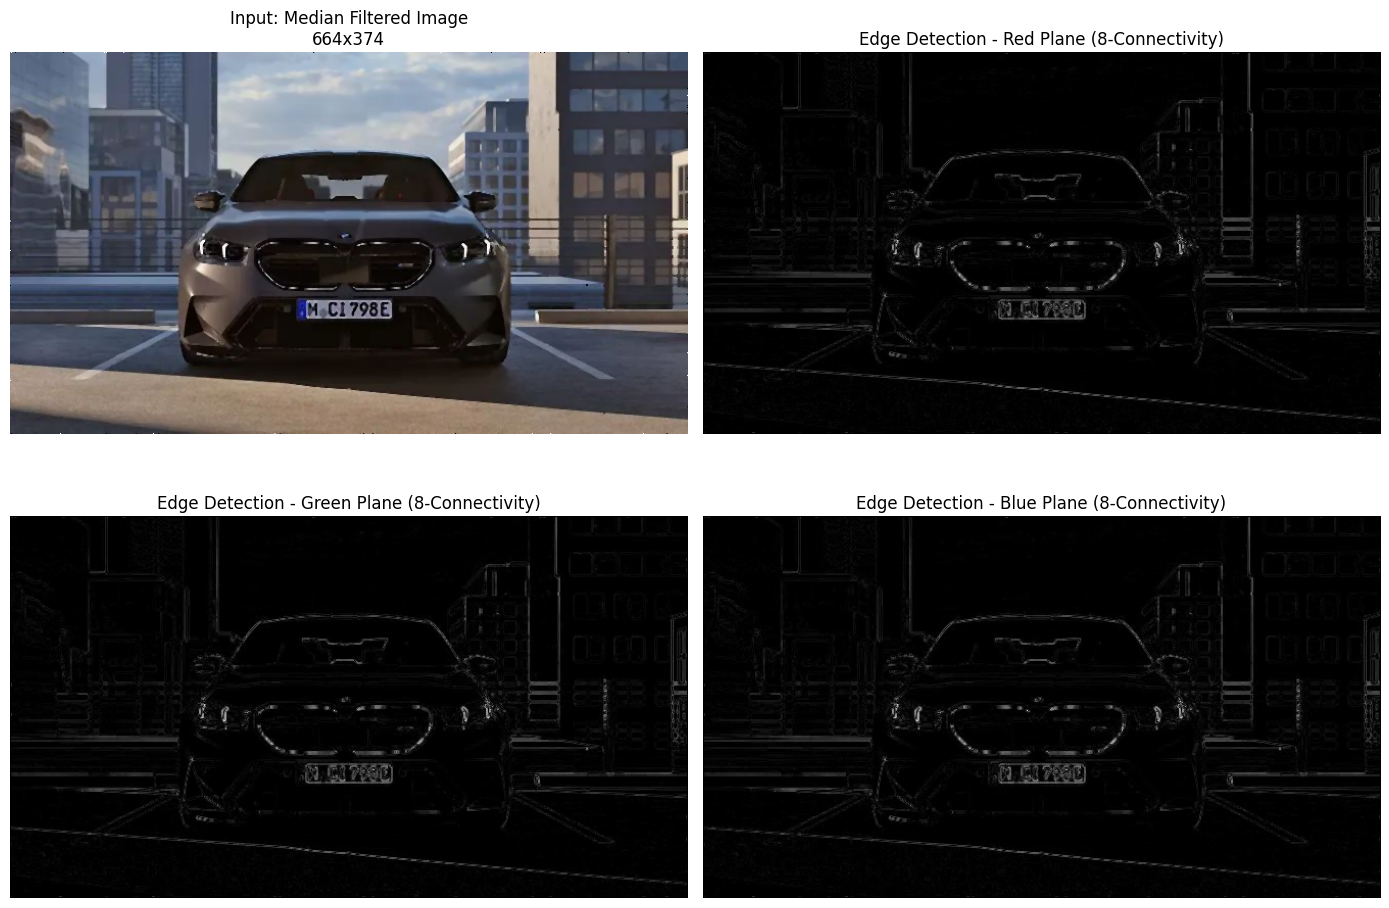

In [29]:
# Display edge detection results (8-connectivity) - each RGB plane separately
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Original image
axs[0, 0].imshow(med_img)
axs[0, 0].axis("off")
axs[0, 0].set_title(f"Input: Median Filtered Image\n{med_img.shape[1]}x{med_img.shape[0]}")

# Red plane
axs[0, 1].imshow(lap_8d_edges[:, :, 0], cmap='gray')
axs[0, 1].axis("off")
axs[0, 1].set_title("Edge Detection - Red Plane (8-Connectivity)")

# Green plane
axs[1, 0].imshow(lap_8d_edges[:, :, 1], cmap='gray')
axs[1, 0].axis("off")
axs[1, 0].set_title("Edge Detection - Green Plane (8-Connectivity)")

# Blue plane
axs[1, 1].imshow(lap_8d_edges[:, :, 2], cmap='gray')
axs[1, 1].axis("off")
axs[1, 1].set_title("Edge Detection - Blue Plane (8-Connectivity)")

plt.tight_layout()
plt.show()

In [30]:
# Apply sharpening: Image - Laplacian
sharpened_4d = med_img_float - lap_4d_img
sharpened_8d = med_img_float - lap_8d_img

# Bring out of range pixel values within range [0, 255]
sharpened_4d_clipped = np.clip(sharpened_4d, 0, 255).astype(np.uint8)
sharpened_8d_clipped = np.clip(sharpened_8d, 0, 255).astype(np.uint8)

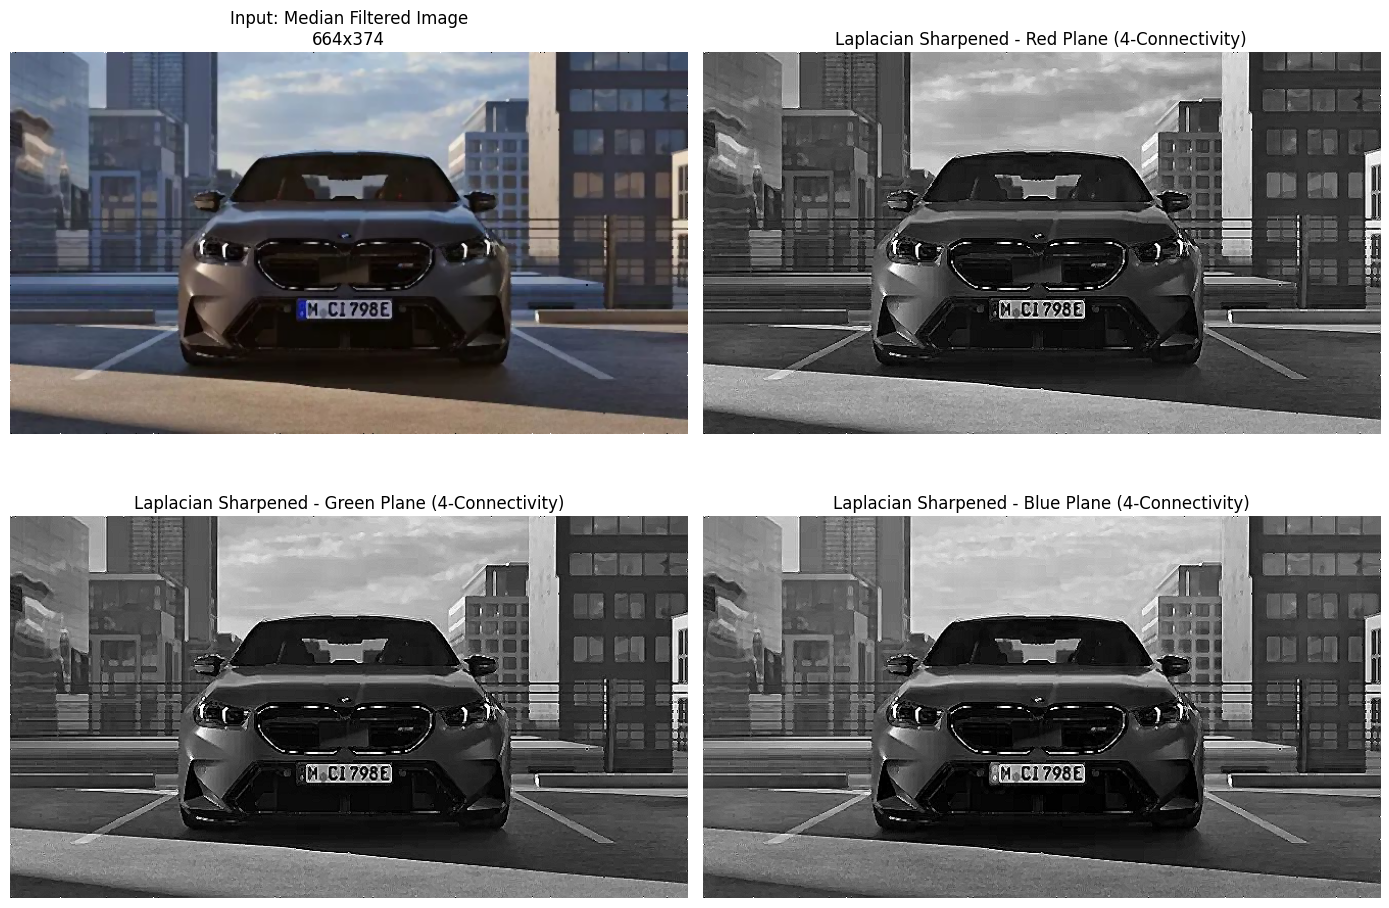

In [31]:
# Display input and output for sharpening (4-connectivity) - each RGB plane separately
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Original image
axs[0, 0].imshow(med_img)
axs[0, 0].axis("off")
axs[0, 0].set_title(f"Input: Median Filtered Image\n{med_img.shape[1]}x{med_img.shape[0]}")

# Red plane
axs[0, 1].imshow(sharpened_4d_clipped[:, :, 0], cmap='gray')
axs[0, 1].axis("off")
axs[0, 1].set_title("Laplacian Sharpened - Red Plane (4-Connectivity)")

# Green plane
axs[1, 0].imshow(sharpened_4d_clipped[:, :, 1], cmap='gray')
axs[1, 0].axis("off")
axs[1, 0].set_title("Laplacian Sharpened - Green Plane (4-Connectivity)")

# Blue plane
axs[1, 1].imshow(sharpened_4d_clipped[:, :, 2], cmap='gray')
axs[1, 1].axis("off")
axs[1, 1].set_title("Laplacian Sharpened - Blue Plane (4-Connectivity)")

plt.tight_layout()
plt.show()

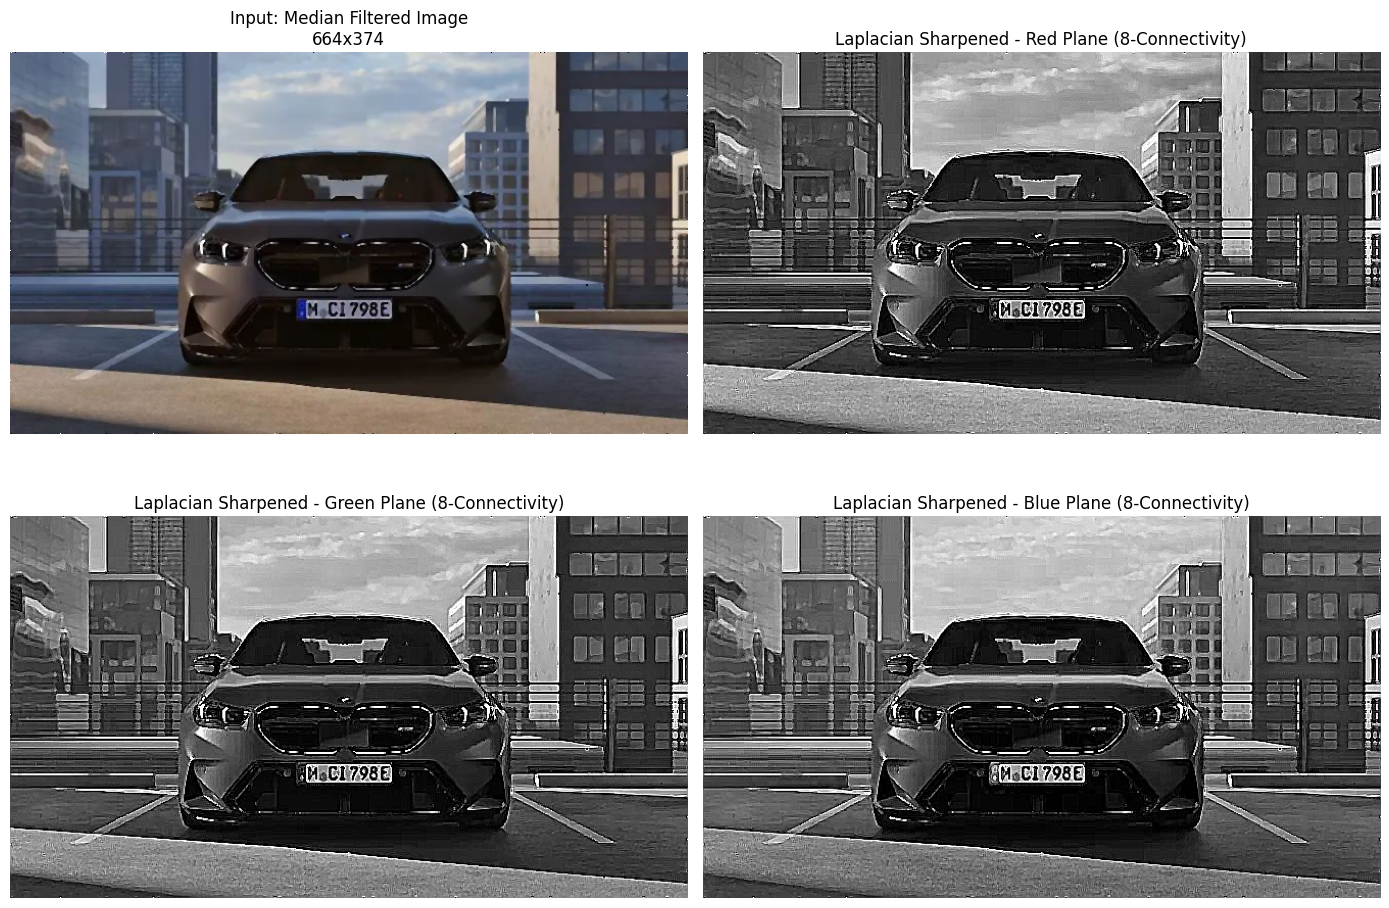

In [32]:
# Display input and output for sharpening (8-connectivity) - each RGB plane separately
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Original image
axs[0, 0].imshow(med_img)
axs[0, 0].axis("off")
axs[0, 0].set_title(f"Input: Median Filtered Image\n{med_img.shape[1]}x{med_img.shape[0]}")

# Red plane
axs[0, 1].imshow(sharpened_8d_clipped[:, :, 0], cmap='gray')
axs[0, 1].axis("off")
axs[0, 1].set_title("Laplacian Sharpened - Red Plane (8-Connectivity)")

# Green plane
axs[1, 0].imshow(sharpened_8d_clipped[:, :, 1], cmap='gray')
axs[1, 0].axis("off")
axs[1, 0].set_title("Laplacian Sharpened - Green Plane (8-Connectivity)")

# Blue plane
axs[1, 1].imshow(sharpened_8d_clipped[:, :, 2], cmap='gray')
axs[1, 1].axis("off")
axs[1, 1].set_title("Laplacian Sharpened - Blue Plane (8-Connectivity)")

plt.tight_layout()
plt.show()